# IMPORT

In [1]:
from google.colab import drive
drive.mount("/content/mount")

Mounted at /content/mount


In [2]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,911 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', family='NanumBarunGothic')

file_path = "/content/태림_필터링데이터(찐).xlsx"

df = pd.read_excel(file_path)

In [2]:
df

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,A0028219,PO348384,20240521-004,May,2024,27,4.800,pc,FIRM,SEA,NaN,1.656.750
1,A0028219,A0028219,PO348384,20240521-004,June,2024,3,4.800,pc,FIRM,SEA,NaN,1.656.750
2,A0028219,A0028219,PO348384,20240521-004,June,2024,10,6.400,pc,FIRM,SEA,NaN,1.656.750
3,A0028219,A0028219,PO348384,20240521-004,June,2024,26,6.400,pc,FORECAST,SEA,NaN,1.656.750
4,A0028219,A0028219,PO348384,20240521-004,July,2024,4,6.400,pc,FORECAST,SEA,NaN,1.656.750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28218,A021N565,A021N565,PO432429,20251110-004,September,2026,28,3.024,PC,FORECAST,SEA,NaN,163.632
28219,A021N565,A021N565,PO432429,20251110-004,October,2026,19,3.024,PC,FORECAST,SEA,NaN,163.632
28220,A021N565,A021N565,PO432429,20251110-004,October,2026,26,2.688,PC,FORECAST,SEA,NaN,163.632
28221,A021N565,A021N565,PO432429,20251110-004,November,2026,2,3.024,PC,FORECAST,SEA,NaN,163.632


# 다시 EDA(제품별로 다시 해본 것)

In [ ]:
MONTH_MAP = {
    'January':1,'February':2,'March':3,'April':4,
    'May':5,'June':6,'July':7,'August':8,
    'September':9,'October':10,'November':11,'December':12
}

df['Month_Num']    = df['Month'].map(MONTH_MAP)
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d', errors='coerce')
df['Target_Date']  = pd.to_datetime(
    dict(year=df['Year'], month=df['Month_Num'], day=df['Day']), errors='coerce'
)
df['Lead_Days'] = (df['Target_Date'] - df['Release_Date']).dt.days

PN_LIST = df['ZF_PN'].value_counts().index.tolist()
print(f"ZF_PN 목록: {PN_LIST}")
print(f"전체 레코드: {len(df):,}건")
df.head(3)


ZF_PN 목록: ['A0070270', 'A0049000', 'A0028219', 'A0067885', 'A021N565', 'A0030814X']
전체 레코드: 28,223건


,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY,Month_Num,Release_Date,Target_Date,Lead_Days
0,A0028219,A0028219,PO348384,20240521-004,May,2024,27,4.8,pc,FIRM,SEA,NaN,1.656.750,5,2024-05-21,2024-05-27,6
1,A0028219,A0028219,PO348384,20240521-004,June,2024,3,4.8,pc,FIRM,SEA,NaN,1.656.750,6,2024-05-21,2024-06-03,13
2,A0028219,A0028219,PO348384,20240521-004,June,2024,10,6.4,pc,FIRM,SEA,NaN,1.656.750,6,2024-05-21,2024-06-10,20


In [ ]:
rows = []
for pn in PN_LIST:
    g = df[df['ZF_PN'] == pn]
    firm  = g[g['Firm/Forecast'] == 'FIRM']
    fc    = g[g['Firm/Forecast'] == 'FORECAST']
    ld    = firm['Lead_Days']
    rows.append({
        'ZF_PN'          : pn,
        '총 레코드'       : len(g),
        'FIRM 건수'       : len(firm),
        'FIRM 비율(%)'    : round(len(firm)/len(g)*100, 1),
        'FORECAST 건수'   : len(fc),
        'Release 수'      : g['ID_Release'].nunique(),
        'FIRM Lead 평균'  : round(ld.mean(), 1),
        'FIRM Lead 중앙값': round(ld.median(), 1),
        'FIRM Lead 75%'  : round(ld.quantile(.75), 1),
        '평균 Qty'        : round(g['Quantity'].mean(), 2),
    })

summary = pd.DataFrame(rows).set_index('ZF_PN')
print("=" * 60)
print("품번별 요약 통계")
print("=" * 60)
print(summary.to_string())

품번별 요약 통계
           총 레코드  FIRM 건수  FIRM 비율(%)  FORECAST 건수  Release 수  FIRM Lead 평균  FIRM Lead 중앙값  FIRM Lead 75%  평균 Qty
ZF_PN                                                                                                            
A0070270    5960      179         3.0         5781         77           8.5            9.0           16.0    8.10
A0049000    5359      307         5.7         5052         77          10.7           11.0           18.0   26.18
A0028219    5121      274         5.4         4847         77          11.9           14.0           21.0    5.05
A0067885    4780      211         4.4         4569         77          10.0           10.0           17.5    6.49
A021N565    4657      215         4.6         4442         77          17.7           15.0           24.0    5.72
A0030814X   2346      186         7.9         2160         77          10.2           11.0           20.8    3.50


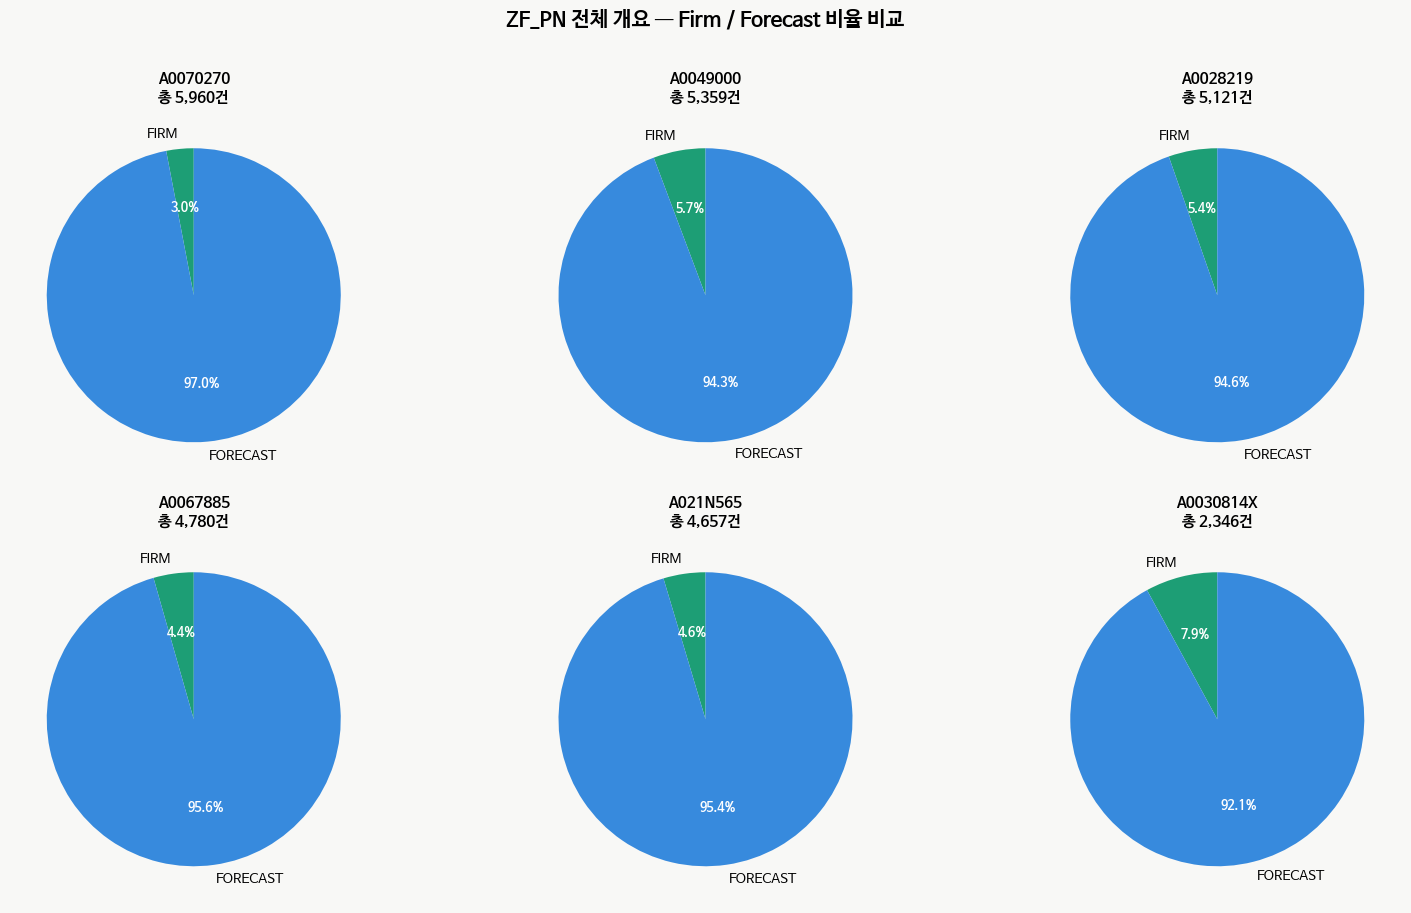

In [ ]:
COLORS = {
    'FIRM'    : '#1D9E75',
    'FORECAST': '#378ADD',
    'firm2'   : '#7F77DD',
    'bg'      : '#F8F8F6',
    'line'    : '#E0E0DC',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('ZF_PN 전체 개요 — Firm / Forecast 비율 비교', fontsize=15, fontweight='bold', y=1.01)

for ax, pn in zip(axes.flat, PN_LIST):
    g     = df[df['ZF_PN'] == pn]
    firm  = (g['Firm/Forecast'] == 'FIRM').sum()
    fc    = (g['Firm/Forecast'] == 'FORECAST').sum()
    total = len(g)

    ax.set_facecolor(COLORS['bg'])
    wedges, texts, autotexts = ax.pie(
        [firm, fc],
        labels=['FIRM', 'FORECAST'],
        colors=[COLORS['FIRM'], COLORS['FORECAST']],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(linewidth=0),
        textprops=dict(fontsize=10),
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
        at.set_color('white')

    ax.set_title(f'{pn}\n총 {total:,}건', fontsize=11, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('01_overall_pie.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

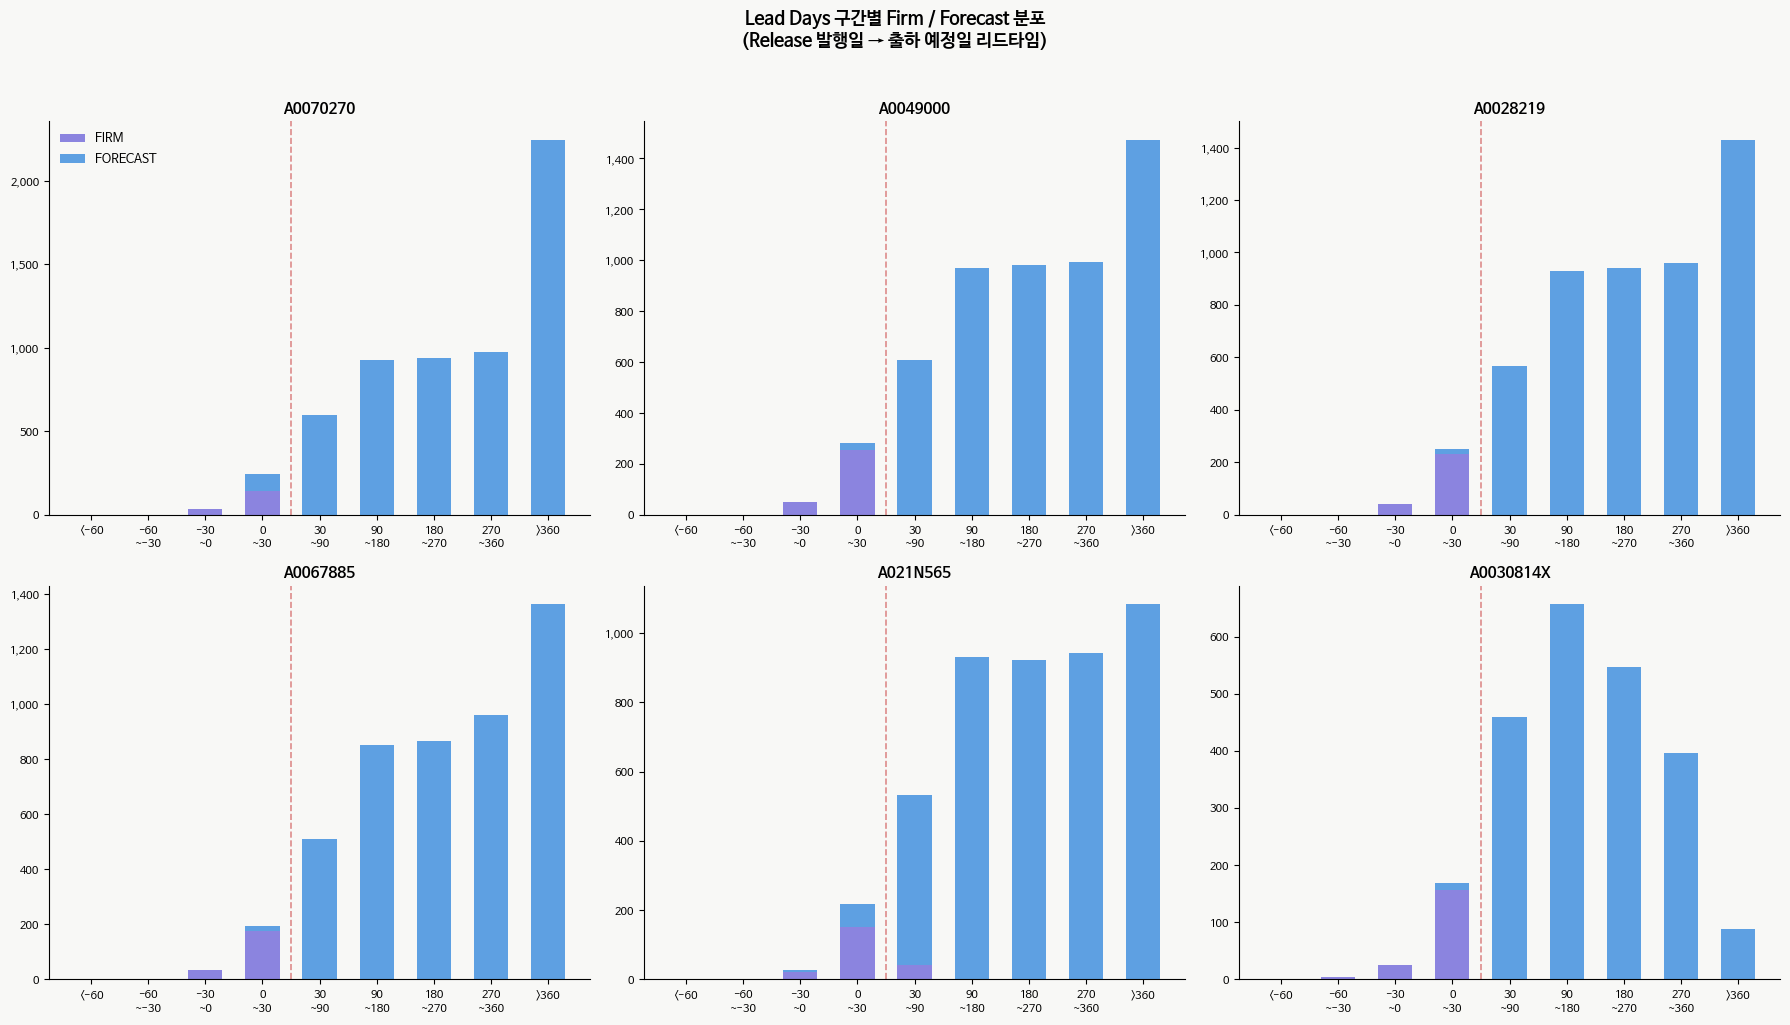

In [ ]:
bins   = [-float('inf'), -60, -30, 0, 30, 90, 180, 270, 360, float('inf')]
labels = ['<-60','-60\n~-30','-30\n~0','0\n~30','30\n~90','90\n~180','180\n~270','270\n~360','>360']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Lead Days 구간별 Firm / Forecast 분포\n(Release 발행일 → 출하 예정일 리드타임)', fontsize=13, fontweight='bold', y=1.02)

for ax, pn in zip(axes.flat, PN_LIST):
    g = df[df['ZF_PN'] == pn].copy()
    g['Lead_Bin'] = pd.cut(g['Lead_Days'], bins=bins, labels=labels)

    pivot = (g.groupby(['Lead_Bin', 'Firm/Forecast'], observed=True)
              .size().unstack(fill_value=0))
    if 'FIRM' not in pivot.columns:
        pivot['FIRM'] = 0
    if 'FORECAST' not in pivot.columns:
        pivot['FORECAST'] = 0

    pivot = pivot.reindex(labels, fill_value=0)

    x = range(len(labels))
    ax.set_facecolor(COLORS['bg'])
    ax.bar(x, pivot['FIRM'],     color=COLORS['firm2'],    label='FIRM',     alpha=0.9, width=0.6)
    ax.bar(x, pivot['FORECAST'], color=COLORS['FORECAST'], label='FORECAST', alpha=0.8, width=0.6,
           bottom=pivot['FIRM'])

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'{pn}', fontsize=11, fontweight='bold')
    ax.set_facecolor(COLORS['bg'])
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))
    if ax == axes.flat[0]:
        ax.legend(fontsize=9, framealpha=0)

    ax.axvline(x=3.5, color='#CC4444', linewidth=1.2, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('02_lead_days_dist.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

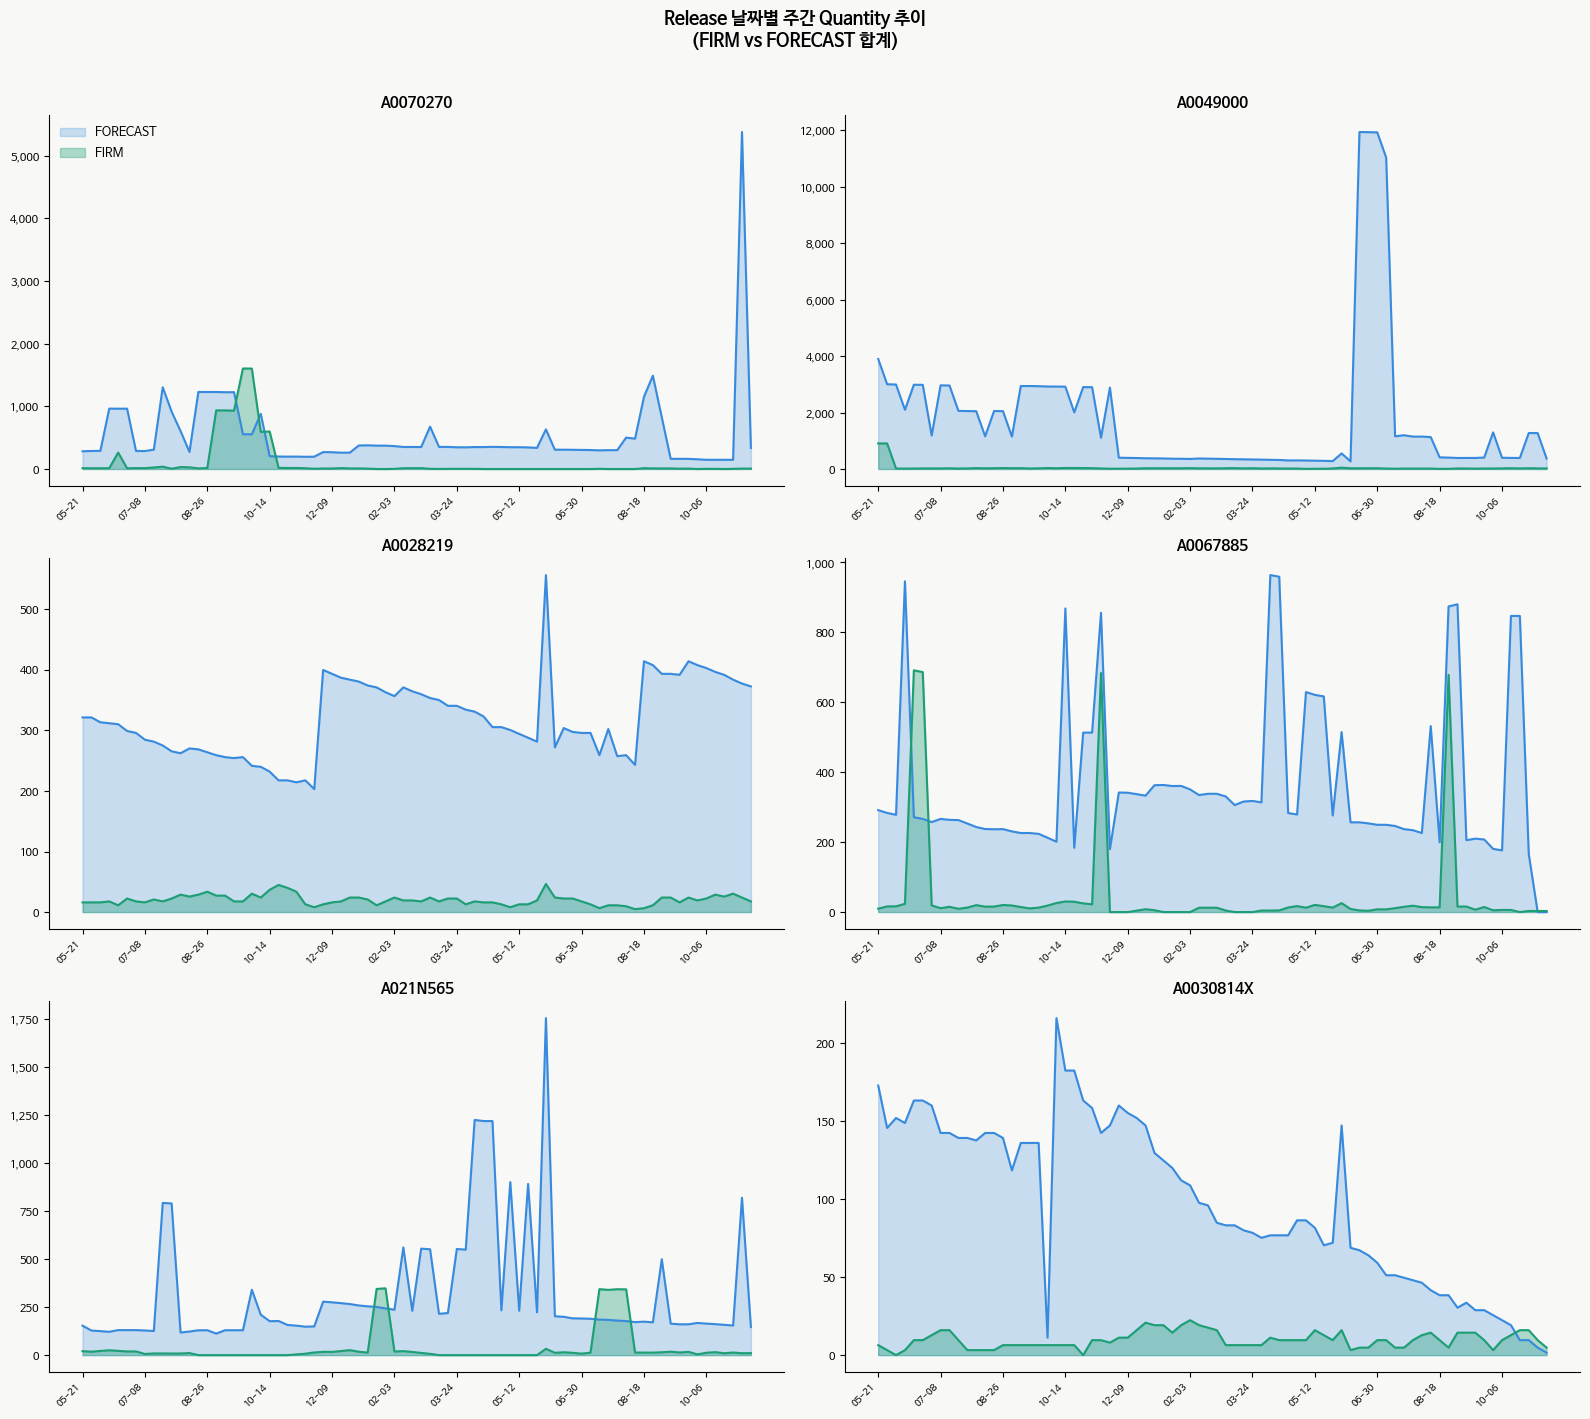

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=False)
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('Release 날짜별 주간 Quantity 추이\n(FIRM vs FORECAST 합계)', fontsize=13, fontweight='bold', y=1.01)

for ax, pn in zip(axes.flat, PN_LIST):
    g = df[df['ZF_PN'] == pn]
    weekly = (g.groupby(['Release_Date', 'Firm/Forecast'])['Quantity']
               .sum().unstack(fill_value=0).sort_index())

    firm_vals = weekly.get('FIRM', pd.Series(dtype=float))
    fc_vals   = weekly.get('FORECAST', pd.Series(dtype=float))
    x = range(len(weekly))

    ax.set_facecolor(COLORS['bg'])
    ax.fill_between(x, fc_vals.values,   color=COLORS['FORECAST'], alpha=0.25, label='FORECAST')
    ax.plot        (x, fc_vals.values,   color=COLORS['FORECAST'], linewidth=1.5)
    ax.fill_between(x, firm_vals.values, color=COLORS['FIRM'],     alpha=0.35, label='FIRM')
    ax.plot        (x, firm_vals.values, color=COLORS['FIRM'],     linewidth=1.5)

    # x축 레이블: 10개만 표시
    step = max(1, len(weekly) // 10)
    tick_pos   = list(range(0, len(weekly), step))
    tick_labels= [str(d.date())[5:] for d in weekly.index[tick_pos]]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha='right')

    ax.set_title(f'{pn}', fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.tick_params(axis='y', labelsize=8)
    if ax == axes.flat[0]:
        ax.legend(fontsize=9, framealpha=0)

plt.tight_layout()
plt.savefig('03_qty_trend.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

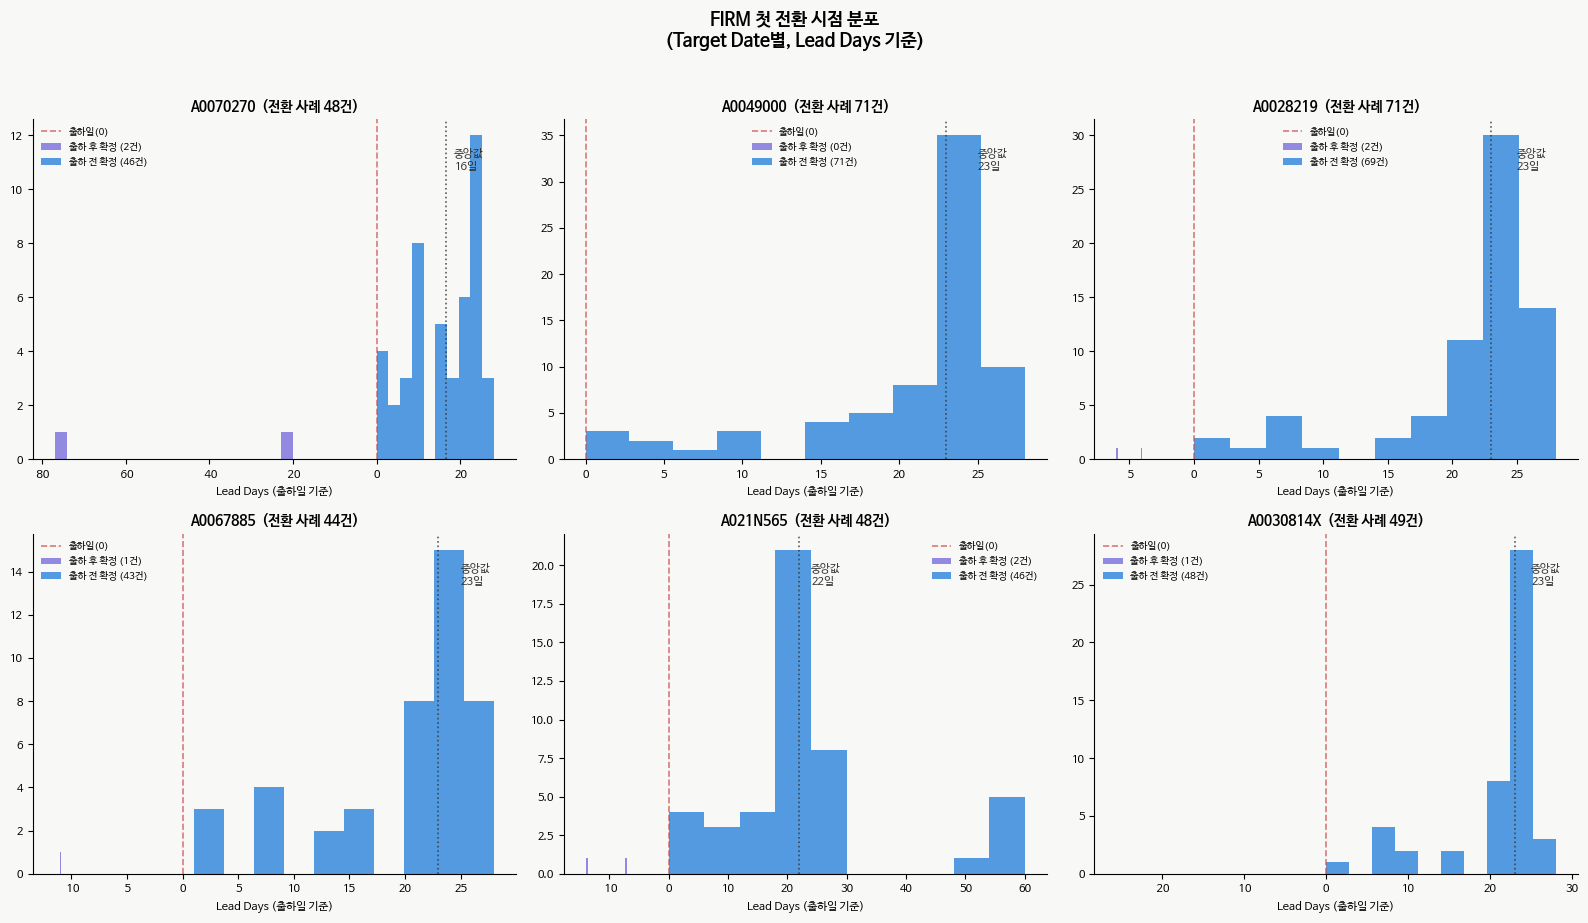

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('FIRM 첫 전환 시점 분포\n(Target Date별, Lead Days 기준)', fontsize=13, fontweight='bold', y=1.02)

for ax, pn in zip(axes.flat, PN_LIST):
    g = df[df['ZF_PN'] == pn]
    firm_targets = g[g['Firm/Forecast'] == 'FIRM']['Target_Date'].unique()

    transitions = []
    for td in firm_targets:
        sub  = g[g['Target_Date'] == td]
        firm = sub[sub['Firm/Forecast'] == 'FIRM']
        fc   = sub[sub['Firm/Forecast'] == 'FORECAST']
        if len(firm) > 0 and len(fc) > 0:
            first_firm_lead = firm.loc[firm['Release_Date'].idxmin(), 'Lead_Days']
            transitions.append(first_firm_lead)

    transitions = pd.Series(transitions).dropna()

    ax.set_facecolor(COLORS['bg'])
    ax.axvline(0, color='#CC4444', linewidth=1.2, linestyle='--', alpha=0.7, label='출하일(0)')

    neg = transitions[transitions < 0]
    pos = transitions[transitions >= 0]
    ax.hist(neg, bins=20, color=COLORS['firm2'],   alpha=0.85, label=f'출하 후 확정 ({len(neg)}건)')
    ax.hist(pos, bins=10, color=COLORS['FORECAST'], alpha=0.85, label=f'출하 전 확정 ({len(pos)}건)')

    med = transitions.median()
    ax.axvline(med, color='#333', linewidth=1.2, linestyle=':', alpha=0.8)
    ax.text(med + 2, ax.get_ylim()[1] * 0.85, f'중앙값\n{med:.0f}일',
            fontsize=8, color='#333')

    ax.set_title(f'{pn}  (전환 사례 {len(transitions)}건)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Lead Days (출하일 기준)', fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, framealpha=0)

plt.tight_layout()
plt.savefig('04_firm_transition.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

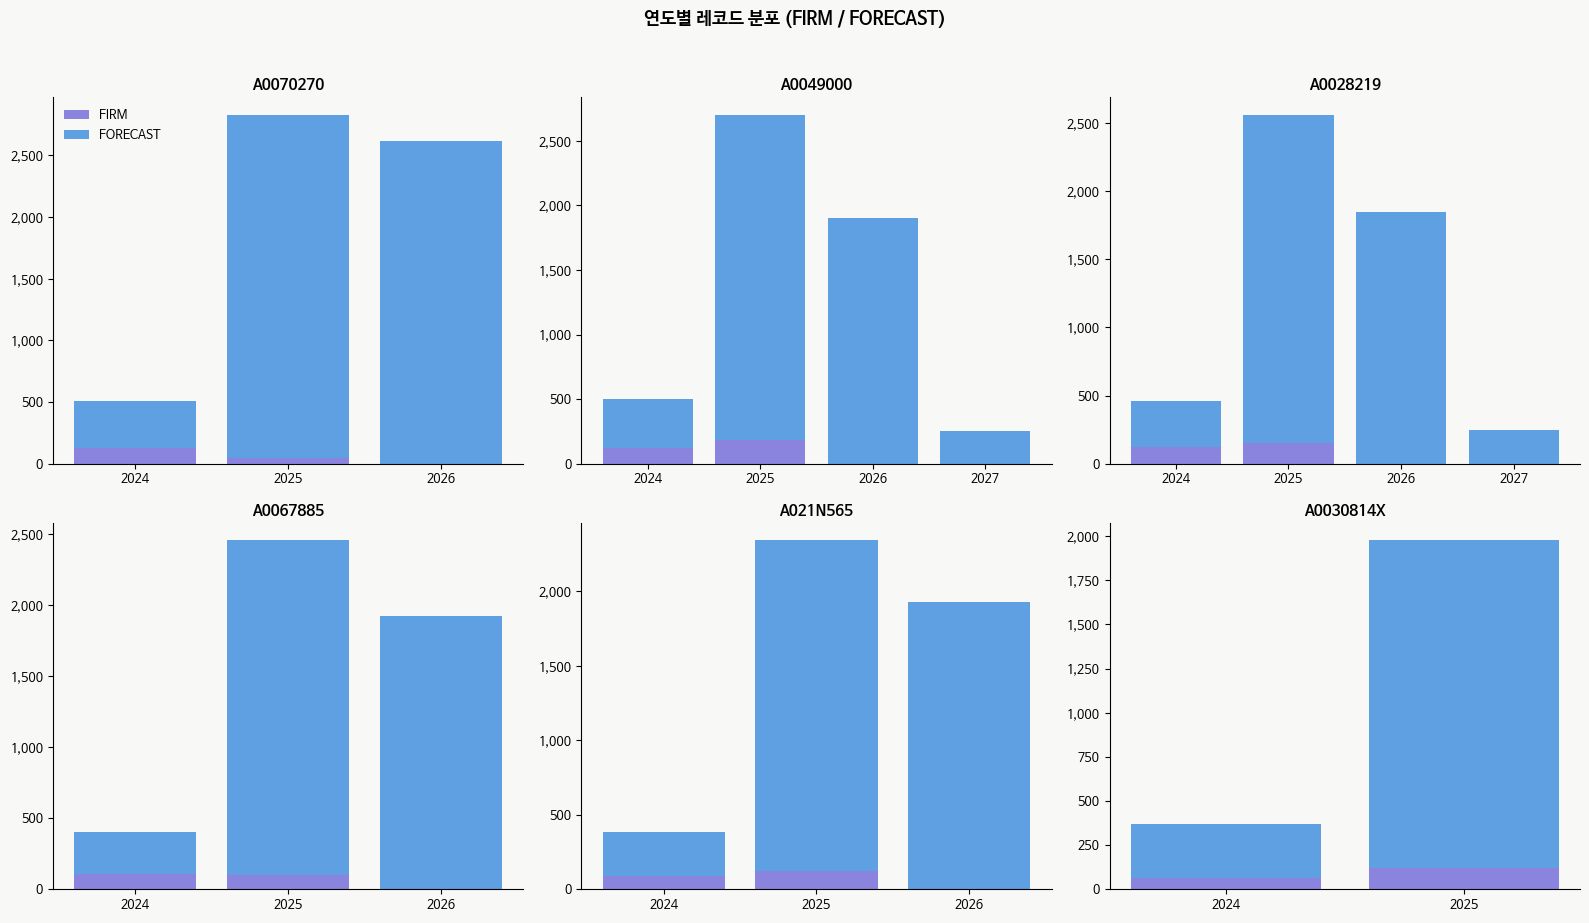

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('연도별 레코드 분포 (FIRM / FORECAST)', fontsize=13, fontweight='bold', y=1.02)

for ax, pn in zip(axes.flat, PN_LIST):
    g     = df[df['ZF_PN'] == pn]
    pivot = (g.groupby(['Year', 'Firm/Forecast'])
              .size().unstack(fill_value=0).sort_index())

    years     = [str(y) for y in pivot.index]
    firm_vals = pivot.get('FIRM', [0]*len(pivot))
    fc_vals   = pivot.get('FORECAST', [0]*len(pivot))

    ax.set_facecolor(COLORS['bg'])
    ax.bar(years, firm_vals, color=COLORS['firm2'],    label='FIRM',     alpha=0.9)
    ax.bar(years, fc_vals,   color=COLORS['FORECAST'], label='FORECAST', alpha=0.8,
           bottom=firm_vals)

    ax.set_title(f'{pn}', fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=9)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))
    if ax == axes.flat[0]:
        ax.legend(fontsize=9, framealpha=0)

plt.tight_layout()
plt.savefig('05_yearly_dist.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()


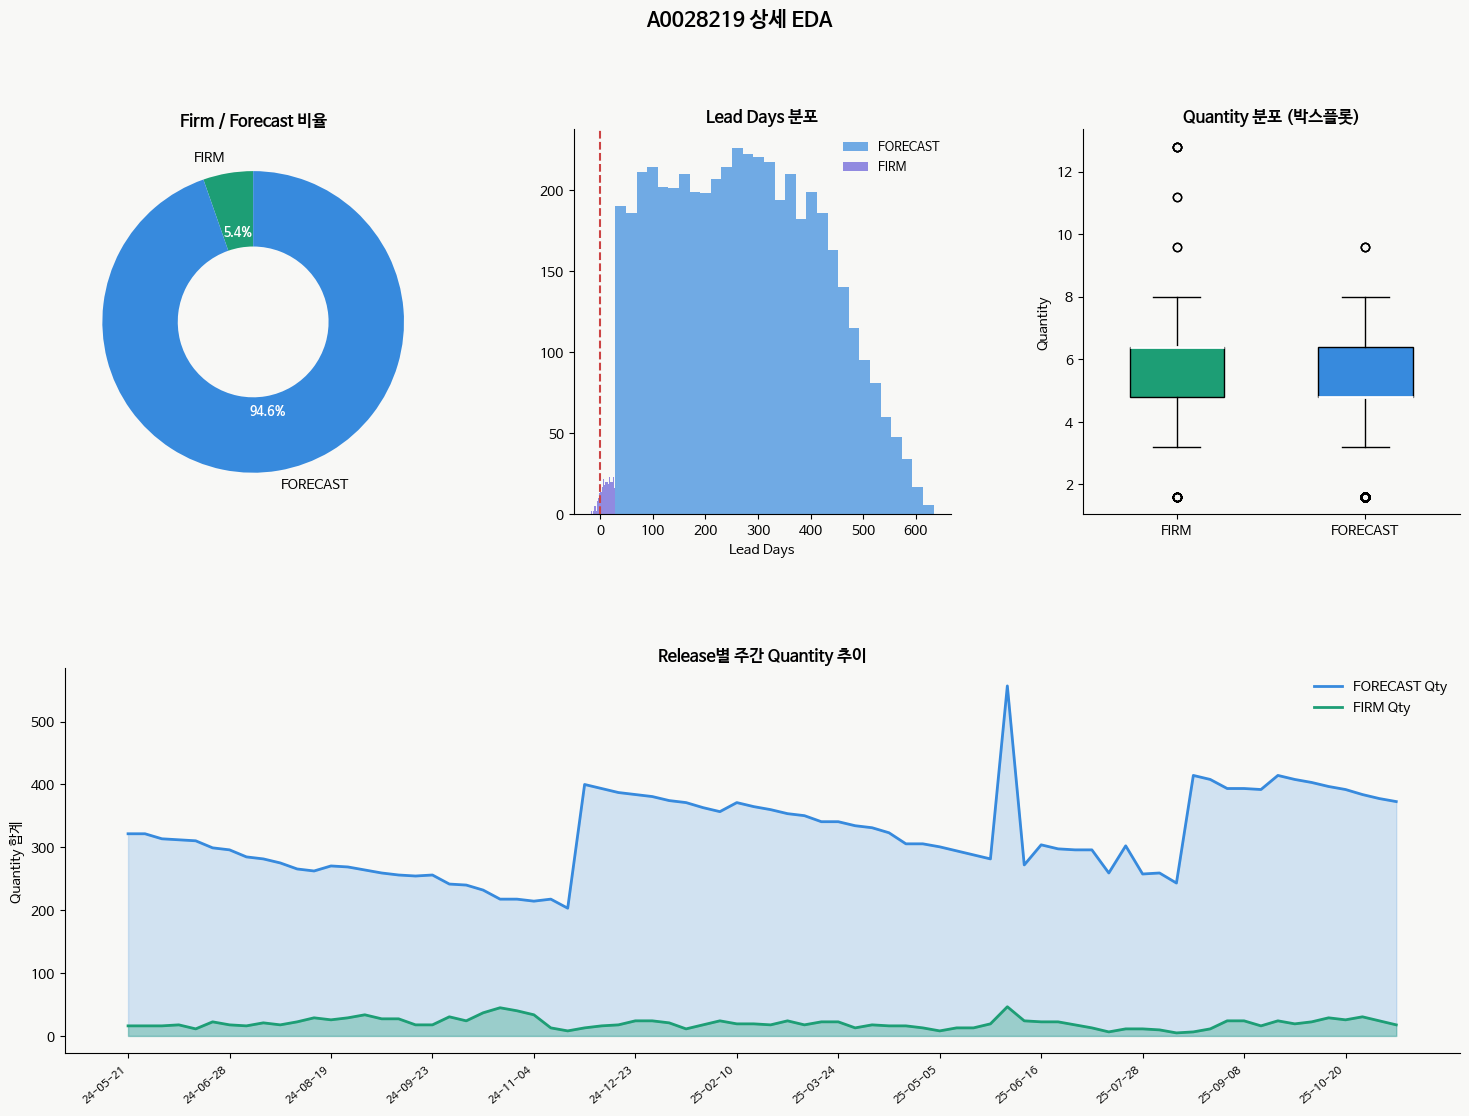

In [ ]:
TARGET_PN = 'A0028219'   # ← 여기서 품번 변경 가능

g = df[df['ZF_PN'] == TARGET_PN].copy()

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle(f'{TARGET_PN} 상세 EDA', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# (1) Donut
ax1 = fig.add_subplot(gs[0, 0])
firm_n = (g['Firm/Forecast'] == 'FIRM').sum()
fc_n   = (g['Firm/Forecast'] == 'FORECAST').sum()
ax1.set_facecolor(COLORS['bg'])
wedges, _, autotexts = ax1.pie(
    [firm_n, fc_n], labels=['FIRM','FORECAST'],
    colors=[COLORS['FIRM'], COLORS['FORECAST']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(linewidth=0, width=0.5),
    textprops=dict(fontsize=10),
)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
ax1.set_title('Firm / Forecast 비율', fontweight='bold')

# (2) Lead Days 히스토그램
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(COLORS['bg'])
firm_ld = g[g['Firm/Forecast'] == 'FIRM']['Lead_Days'].dropna()
fc_ld   = g[g['Firm/Forecast'] == 'FORECAST']['Lead_Days'].dropna()
ax2.hist(fc_ld,   bins=30, color=COLORS['FORECAST'], alpha=0.7, label='FORECAST')
ax2.hist(firm_ld, bins=20, color=COLORS['firm2'],    alpha=0.85, label='FIRM')
ax2.axvline(0, color='#CC4444', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Lead Days')
ax2.set_title('Lead Days 분포', fontweight='bold')
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=9, framealpha=0)

# (3) Qty 박스플롯
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(COLORS['bg'])
data_firm = g[g['Firm/Forecast'] == 'FIRM']['Quantity'].dropna()
data_fc   = g[g['Firm/Forecast'] == 'FORECAST']['Quantity'].dropna()
bp = ax3.boxplot([data_firm, data_fc], labels=['FIRM','FORECAST'],
                 patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(COLORS['FIRM'])
bp['boxes'][1].set_facecolor(COLORS['FORECAST'])
ax3.set_title('Quantity 분포 (박스플롯)', fontweight='bold')
ax3.set_ylabel('Quantity')
ax3.spines[['top','right']].set_visible(False)

# (4) Release별 Qty 추이 (하단 전체 너비)
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor(COLORS['bg'])
weekly = (g.groupby(['Release_Date', 'Firm/Forecast'])['Quantity']
           .sum().unstack(fill_value=0).sort_index())
x = range(len(weekly))
fv = weekly.get('FIRM',     pd.Series(dtype=float))
cv = weekly.get('FORECAST', pd.Series(dtype=float))
ax4.fill_between(x, cv.values, color=COLORS['FORECAST'], alpha=0.2)
ax4.plot(x, cv.values, color=COLORS['FORECAST'], linewidth=2, label='FORECAST Qty')
ax4.fill_between(x, fv.values, color=COLORS['FIRM'],     alpha=0.3)
ax4.plot(x, fv.values, color=COLORS['FIRM'],     linewidth=2, label='FIRM Qty')
step = max(1, len(weekly) // 12)
ax4.set_xticks(list(range(0, len(weekly), step)))
ax4.set_xticklabels(
    [str(d.date())[2:] for d in weekly.index[::step]],
    rotation=40, ha='right', fontsize=8
)
ax4.set_title('Release별 주간 Quantity 추이', fontweight='bold')
ax4.set_ylabel('Quantity 합계')
ax4.spines[['top','right']].set_visible(False)
ax4.legend(fontsize=10, framealpha=0)
ax4.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))

fname = f'06_detail_{TARGET_PN}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

- Cell 2전처리 (날짜 파싱, Lead_Days 계산)
- Cell 36개 품번 요약 통계 테이블 출력
- Cell 4전체 개요 — Firm/Forecast 비율 Donut 차트 (6개)
- Cell 5Lead Days 구간별 누적 막대 (6개 비교)
- Cell 6Release별 Qty 추이 라인 차트 (6개)
- Cell 7Firm 첫 전환 시점 히스토그램 (6개)
- Cell 8연도별 누적 막대 (6개 비교)
- Cell 품범 상세 분석 까지

# 신규 주문 발생 2번째

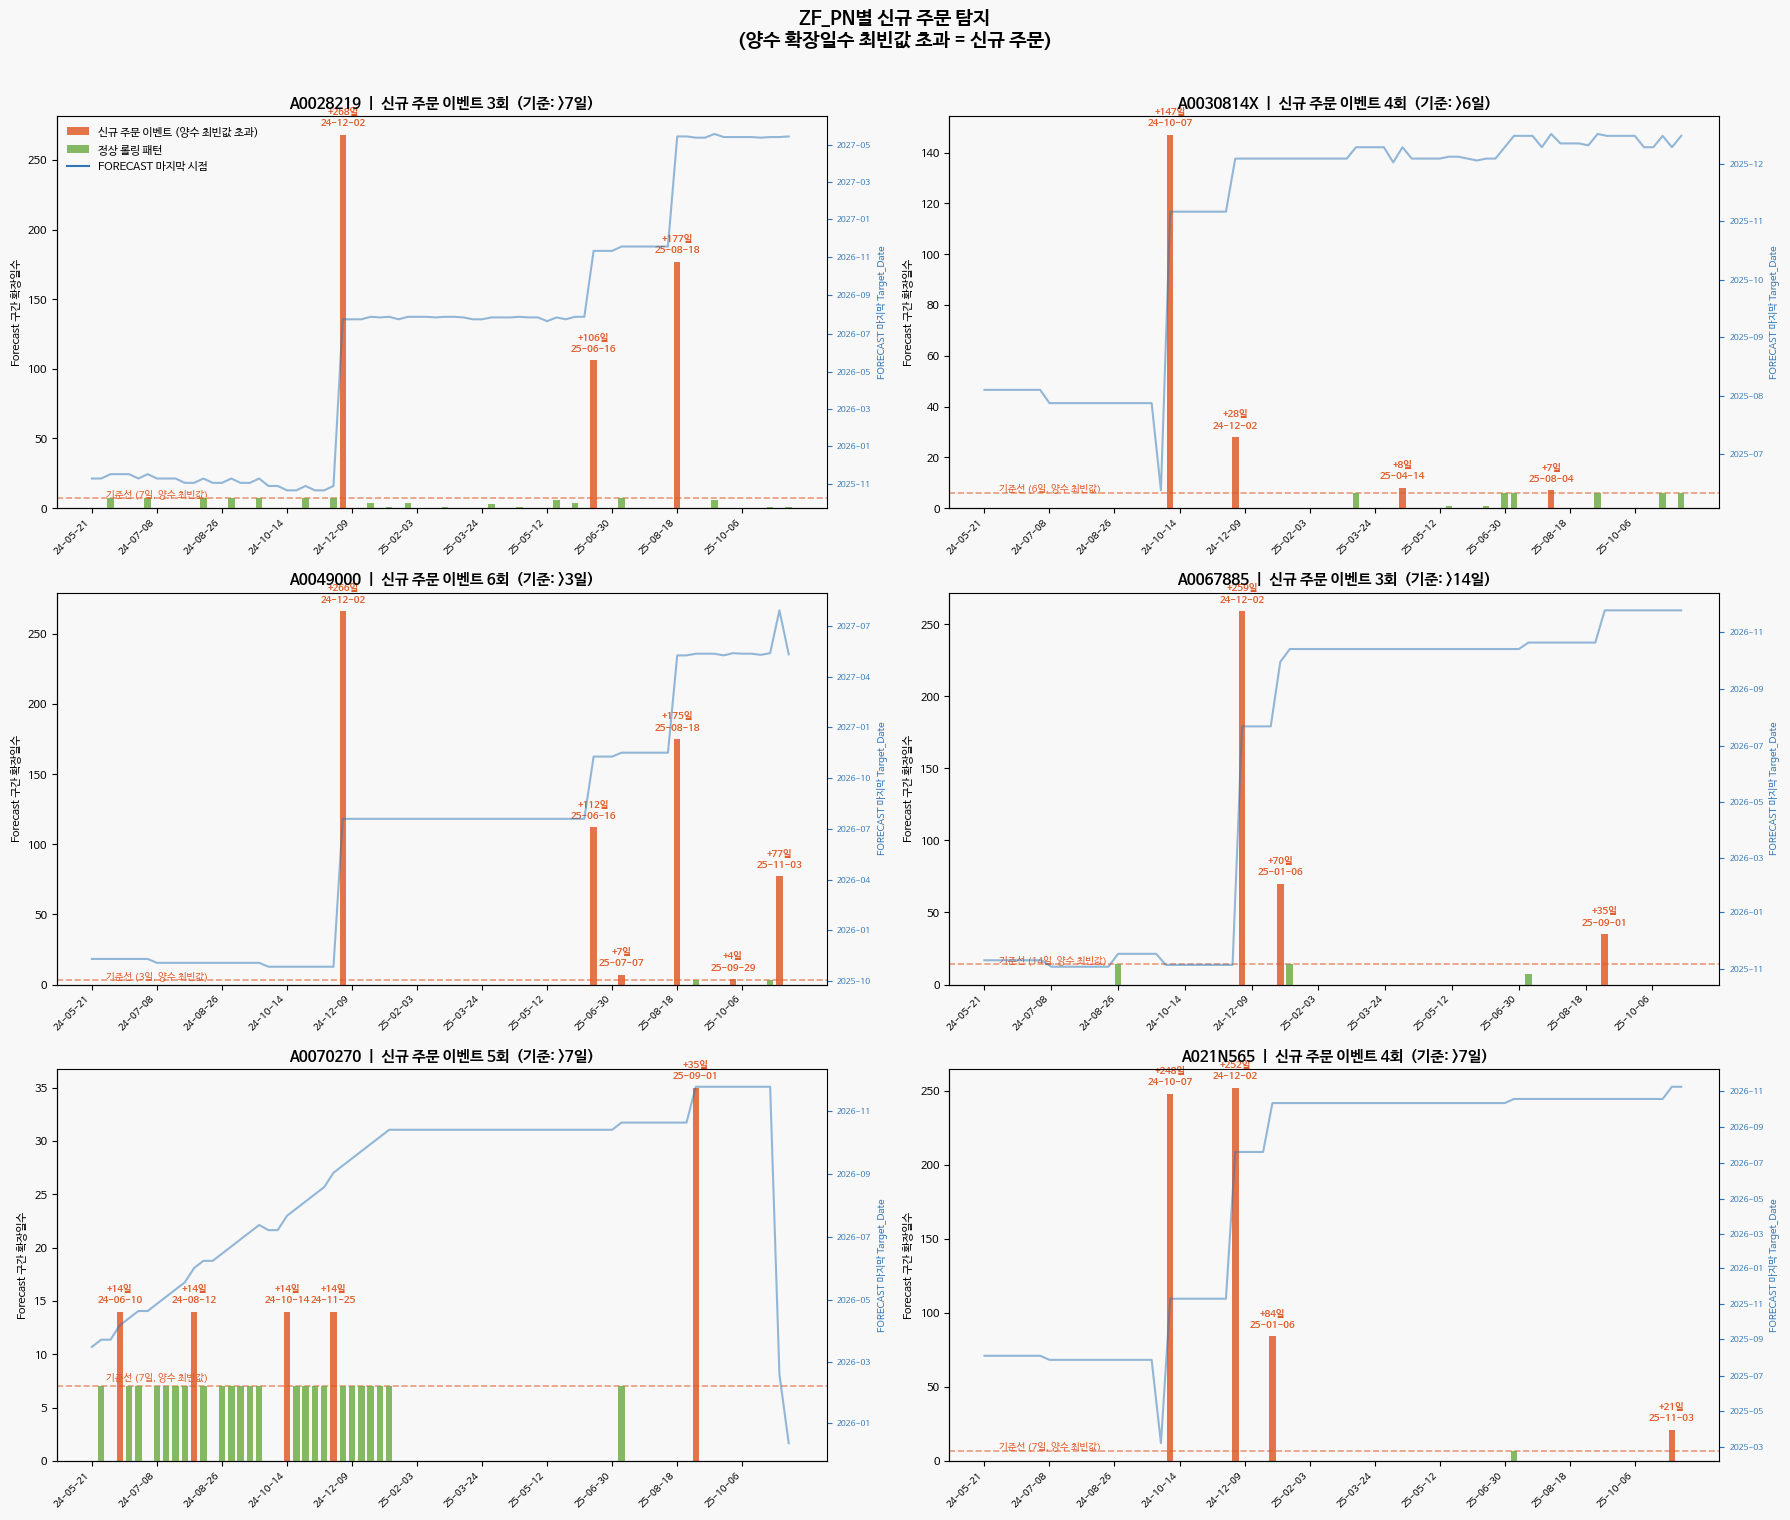

ZF_PN별 신규 주문 이벤트 요약 (양수 최빈값 초과 기준)

▶ A0028219  |  정상 패턴: 7일  |  신규 주문: 3회
  Release_Date       확장일수       확장 전 마지막       확장 후 마지막
  --------------------------------------------------------
  2024-12-02         268일      2025-10-29      2026-07-24
  2025-06-16         106일      2026-07-28      2026-11-11
  2025-08-18         177일      2026-11-18      2027-05-14

▶ A0030814X  |  정상 패턴: 6일  |  신규 주문: 4회
  Release_Date       확장일수       확장 전 마지막       확장 후 마지막
  --------------------------------------------------------
  2024-10-07         147일      2025-06-12      2025-11-06
  2024-12-02          28일      2025-11-06      2025-12-04
  2025-04-14           8일      2025-12-02      2025-12-10
  2025-08-04           7일      2025-12-10      2025-12-17

▶ A0049000  |  정상 패턴: 3일  |  신규 주문: 6회
  Release_Date       확장일수       확장 전 마지막       확장 후 마지막
  --------------------------------------------------------
  2024-12-02         266일      2025-10-27      2026-07-20
  2025-06-16         112일      2026

In [10]:
month_map = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}
df['month_num']    = df['Month'].map(month_map)
df['Target_Date']  = pd.to_datetime(dict(year=df['Year'], month=df['month_num'], day=df['Day']), errors='coerce')
df['Release_Date'] = pd.to_datetime(df['ID_Release'].str[:8], format='%Y%m%d', errors='coerce')

PN_LIST = sorted(df['ZF_PN'].unique().tolist())

COLORS = {
    'bg':        '#F8F8F8',
    'FORECAST':  '#70AD47',
    'new_order': '#E05C2A',
    'line':      '#2E75B6',
}

# ── 핵심 탐지 함수 ────────────────────────────────────────
def detect_forecast_expansion(df, pn):
    """
    양수 확장일수 중 최빈값(가장 자주 반복되는 값) = 정상 롤링 패턴.
    그보다 큰 값이 나오는 순간 = 신규 주문 유입.
    """
    g = df[(df['ZF_PN'] == pn) & (df['Firm/Forecast'] == 'FORECAST')]

    summary = (g.groupby('Release_Date')
                .agg(Max_Target=('Target_Date', 'max'),
                     Total_Qty=('Quantity', 'sum'))
                .sort_index()
                .reset_index())

    summary['Prev_Max_Target'] = summary['Max_Target'].shift(1)
    summary['Expansion_Days']  = (summary['Max_Target'] - summary['Prev_Max_Target']).dt.days

    # ── 핵심: 양수 중 최빈값 = 정상 패턴, 그 초과 = 신규 주문 ──
    pos_exp   = summary['Expansion_Days'][summary['Expansion_Days'] > 0].dropna()
    mode_val  = pos_exp.mode()[0] if len(pos_exp) > 0 else 0
    threshold = mode_val  # 최빈값 초과부터 신규 주문

    summary['Mode_Val']     = mode_val
    summary['Threshold']    = threshold
    summary['Is_New_Order'] = summary['Expansion_Days'] > threshold

    return summary

# ── 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=False)
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('ZF_PN별 신규 주문 탐지\n(양수 확장일수 최빈값 초과 = 신규 주문)',
             fontsize=14, fontweight='bold', y=1.01)

all_summaries = {}

for ax, pn in zip(axes.flat, PN_LIST):
    summary   = detect_forecast_expansion(df, pn)
    all_summaries[pn] = summary

    x         = range(len(summary))
    events    = summary[summary['Is_New_Order']]
    threshold = summary['Threshold'].iloc[0]
    mode_val  = summary['Mode_Val'].iloc[0]

    ax.set_facecolor(COLORS['bg'])

    # FORECAST 마지막 시점 라인 (우축)
    ax2 = ax.twinx()
    ax2.plot(x, summary['Max_Target'], color=COLORS['line'],
             linewidth=1.5, alpha=0.5, zorder=2)
    ax2.set_ylabel('FORECAST 마지막 Target_Date', fontsize=7, color=COLORS['line'])
    ax2.tick_params(axis='y', labelsize=6, colors=COLORS['line'])
    ax2.set_facecolor(COLORS['bg'])

    # Expansion_Days 막대 (양수만 표시)
    colors_bar = [COLORS['new_order'] if v else COLORS['FORECAST']
                  for v in summary['Is_New_Order']]
    ax.bar(x, summary['Expansion_Days'].clip(lower=0),
           color=colors_bar, alpha=0.85, width=0.7, zorder=3)

    # 임계선 (최빈값)
    ax.axhline(threshold, color=COLORS['new_order'], linewidth=1.2,
               linestyle='--', alpha=0.6)
    ax.text(len(summary) * 0.02, threshold + 0.5,
            f'기준선 ({threshold:.0f}일, 양수 최빈값)',
            fontsize=7, color=COLORS['new_order'])

    # 이벤트 어노테이션
    for i, row in events.iterrows():
        idx = summary.index.get_loc(i)
        ax.annotate(
            f"+{int(row['Expansion_Days'])}일\n{str(row['Release_Date'])[:10][2:]}",
            xy=(idx, row['Expansion_Days']),
            xytext=(0, 6), textcoords='offset points',
            ha='center', fontsize=7, color=COLORS['new_order'], fontweight='bold'
        )

    # x축 레이블
    step        = max(1, len(summary) // 10)
    tick_pos    = list(range(0, len(summary), step))
    tick_labels = [str(summary['Release_Date'].iloc[i])[:10][2:] for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha='right')

    ax.set_title(f'{pn}  |  신규 주문 이벤트 {len(events)}회  (기준: >{threshold:.0f}일)',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Forecast 구간 확장일수', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{int(v):,}'))

    if ax == axes.flat[0]:
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = [
            Patch(facecolor=COLORS['new_order'], alpha=0.85, label='신규 주문 이벤트 (양수 최빈값 초과)'),
            Patch(facecolor=COLORS['FORECAST'],  alpha=0.85, label='정상 롤링 패턴'),
            Line2D([0], [0], color=COLORS['line'], linewidth=1.5, label='FORECAST 마지막 시점'),
        ]
        ax.legend(handles=legend_elements, fontsize=8, framealpha=0, loc='upper left')

plt.tight_layout()
plt.savefig('07_new_order_detection_v5.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

# ── 요약 테이블 출력 ──────────────────────────────────────
print('=' * 70)
print('ZF_PN별 신규 주문 이벤트 요약 (양수 최빈값 초과 기준)')
print('=' * 70)
for pn, summary in all_summaries.items():
    events    = summary[summary['Is_New_Order']]
    threshold = summary['Threshold'].iloc[0]
    print(f'\n▶ {pn}  |  정상 패턴: {threshold:.0f}일  |  신규 주문: {len(events)}회')
    print(f"  {'Release_Date':<14} {'확장일수':>8} {'확장 전 마지막':>14} {'확장 후 마지막':>14}")
    print(f"  {'-'*56}")
    for _, row in events.iterrows():
        print(f"  {str(row['Release_Date'])[:10]:<14} "
              f"{int(row['Expansion_Days']):>7}일  "
              f"{str(row['Prev_Max_Target'])[:10]:>14}  "
              f"{str(row['Max_Target'])[:10]:>14}")